In [14]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os
import control as ctl

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [15]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read()).get('target')
OPTIONS

{'test': 5, 'axis': 'x'}

In [16]:
PATH = f'../files/test{OPTIONS['test']}/rolling_{OPTIONS['axis']}'
print(PATH)
print(os.listdir(PATH))

../files/test5/rolling_x
['reference', 'info.json', 'target']


In [17]:
TARGET_VAR = 'roll'
LIMITS     = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits')
STATIC_LIMITS  = LIMITS.get('static')
DYNAMIC_LIMITS = LIMITS.get('dynamic')

print(LIMITS)
print(STATIC_LIMITS)
print(DYNAMIC_LIMITS)

{'dynamic': [120, 150], 'static': [200, 300]}
[200, 300]
[120, 150]


# IMPORTANDO DADOS

In [18]:
df = pd.read_csv(f'{PATH}/target/data.csv')
df

,ay,roll,wz,tmp,wy,pitch,e,wx,az,time,ax,yaw
0,-9735,-3351,44339,56.5,6735,-594,0.288,28910,994122,4.768372e-07,58549,10842
1,-12832,-3356,18329,56.5,-18520,-593,0.288,-27558,996188,5.126691e-02,60494,10847
2,-7134,-3356,29671,56.7,5711,-592,0.288,-30478,997481,1.569357e-01,60662,10856
3,-13577,-3353,-4674,56.5,-19853,-593,0.288,26212,1000726,2.522373e-01,58635,10859
4,-11905,-3357,-17612,56.9,29984,-592,0.288,9759,997716,3.592129e-01,56279,10870
...,...,...,...,...,...,...,...,...,...,...,...,...
3272,-8211,-3336,19180,57.7,-12527,-642,0.468,14780,995288,3.271838e+02,62413,13566
3273,-10354,-3334,113,57.4,17786,-644,0.468,-6816,994789,3.272803e+02,59578,13567
3274,-15290,-3335,-4123,57.4,658,-642,0.468,-11937,997383,3.273756e+02,55175,13568
3275,-6010,-3334,11121,57.7,3740,-643,0.468,-5677,997417,3.274734e+02,59546,13570


- Convertendo pra radianos

In [19]:
def convertAxis(df):
    g_mpss = 9.80665
    
    for col in ['ax', 'ay', 'az']:
        df[col] = (df[col] / 1000000.0) * g_mpss

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df


df = convertAxis(df)
df.head()

,ay,roll,wz,tmp,wy,pitch,e,wx,az,time,ax,yaw
0,-0.095468,-3.351,0.44339,56.5,0.06735,-0.594,0.288,0.28910,9.749007,4.768372e-07,0.574170,10.842
1,-0.125839,-3.356,0.18329,56.5,-0.18520,-0.593,0.288,-0.27558,9.769267,5.126691e-02,0.593243,10.847
2,-0.069961,-3.356,0.29671,56.7,0.05711,-0.592,0.288,-0.30478,9.781947,1.569357e-01,0.594891,10.856
3,-0.133145,-3.353,-0.04674,56.5,-0.19853,-0.593,0.288,0.26212,9.813770,2.522373e-01,0.575013,10.859
4,-0.116748,-3.357,-0.17612,56.9,0.29984,-0.592,0.288,0.09759,9.784252,3.592129e-01,0.551908,10.870


- Formatando as colunas pra ficar igual a de referência

In [20]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

df = switchColumns(df, 'roll', 'pitch')
df = switchColumns(df, 'wy', 'wz')
df = switchColumns(df, 'ay', 'az')

df['wy'] = -df['wy']
df['pitch'] = -df['pitch']

df.head()

,ay,roll,wz,tmp,wy,pitch,e,wx,az,time,ax,yaw
0,9.749007,-0.594,0.06735,56.5,-0.44339,3.351,0.288,0.28910,-0.095468,4.768372e-07,0.574170,10.842
1,9.769267,-0.593,-0.18520,56.5,-0.18329,3.356,0.288,-0.27558,-0.125839,5.126691e-02,0.593243,10.847
2,9.781947,-0.592,0.05711,56.7,-0.29671,3.356,0.288,-0.30478,-0.069961,1.569357e-01,0.594891,10.856
3,9.813770,-0.593,-0.19853,56.5,0.04674,3.353,0.288,0.26212,-0.133145,2.522373e-01,0.575013,10.859
4,9.784252,-0.592,0.29984,56.9,0.17612,3.357,0.288,0.09759,-0.116748,3.592129e-01,0.551908,10.870


In [21]:
removed = df[df.duplicated(subset=['time'], keep='first')]
df      = df.drop_duplicates(subset=['time'], keep='first')
removed

,ay,roll,wz,tmp,wy,pitch,e,wx,az,time,ax,yaw


# VISUALIZAÇÃO DE VARIÁVEIS

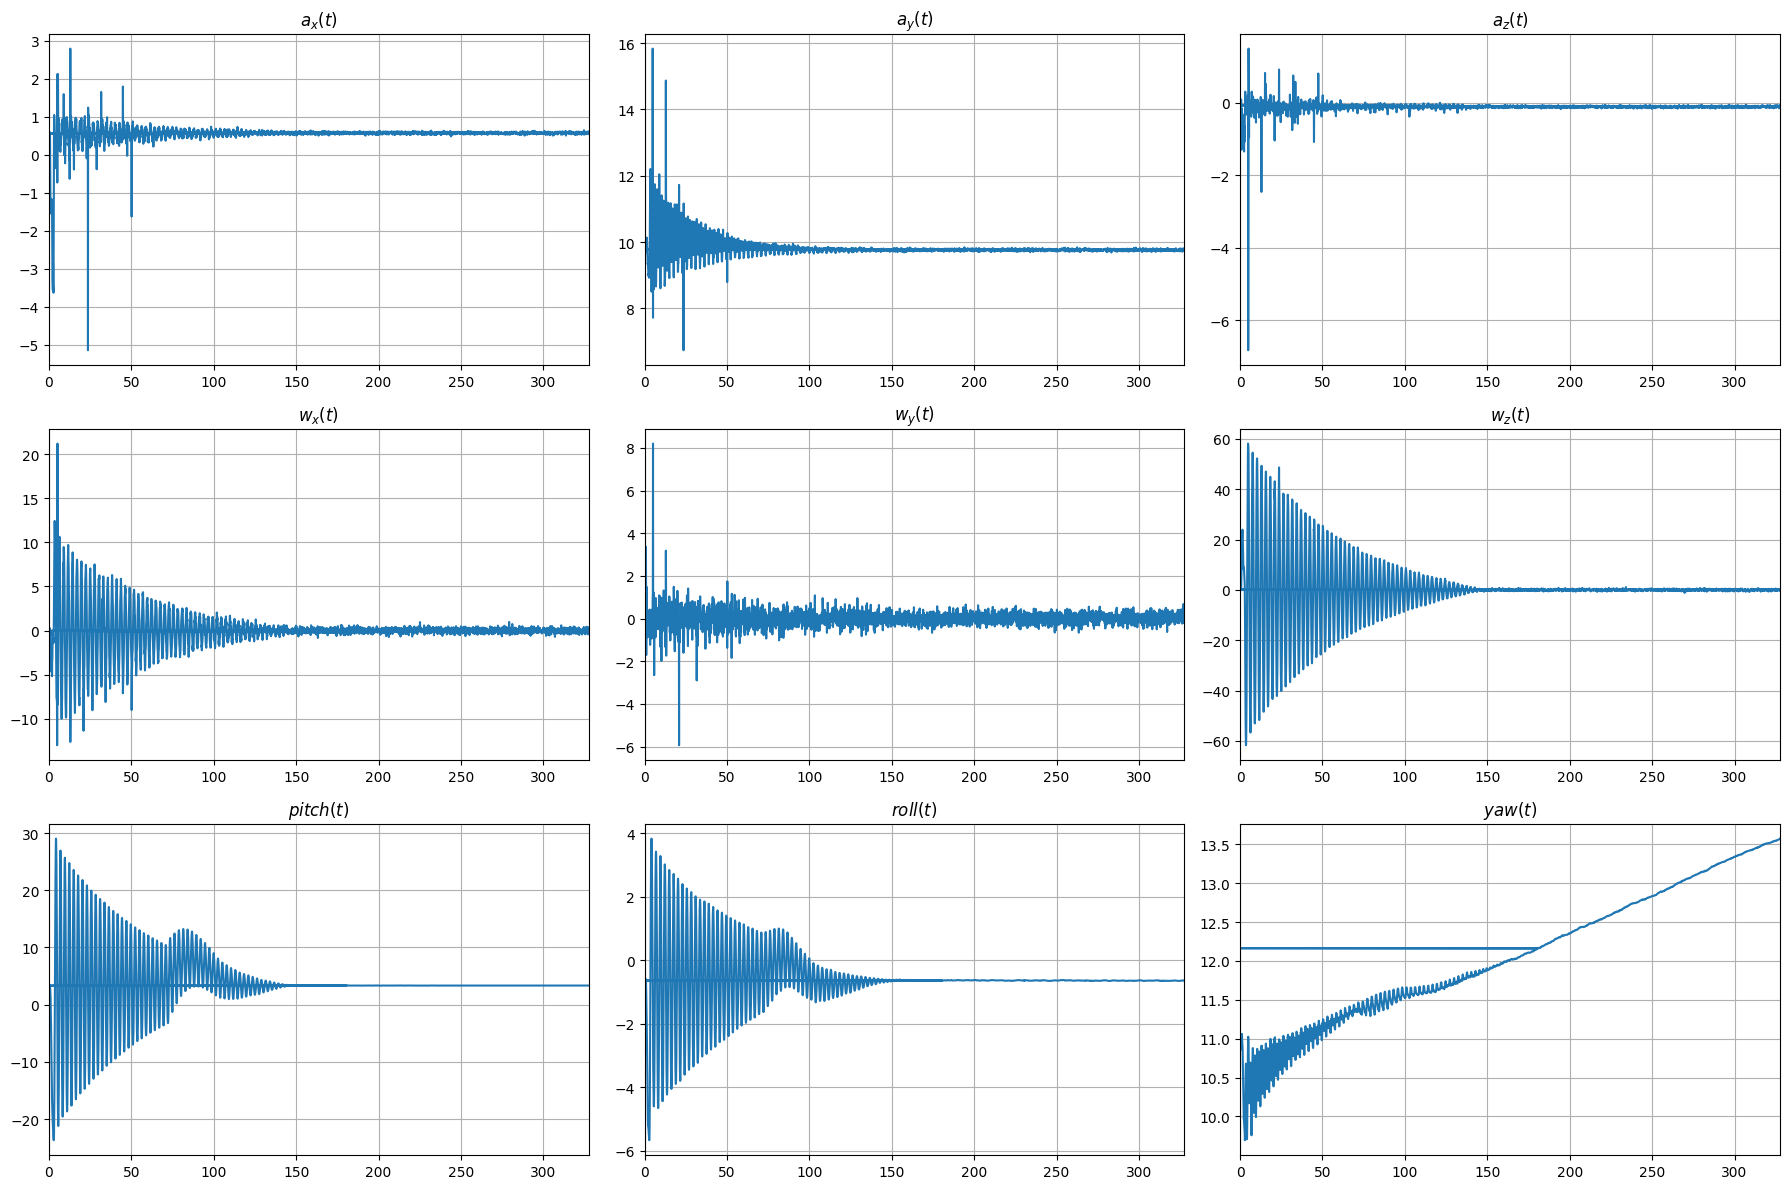

In [22]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = (t_max - t_min)
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

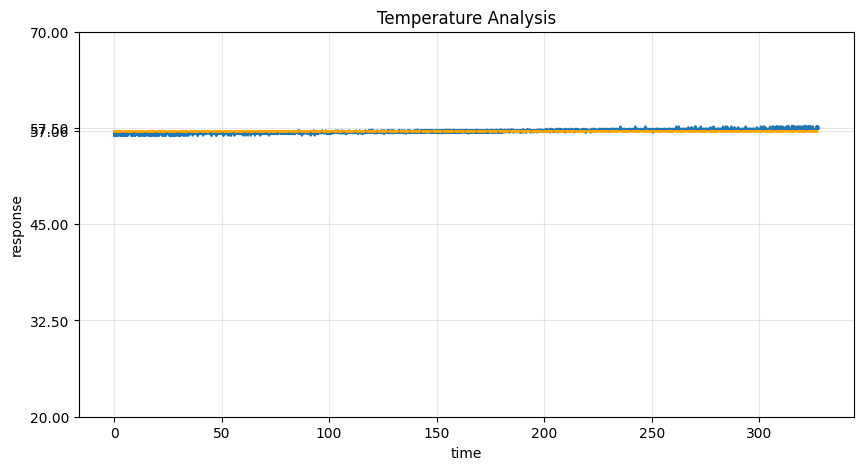

In [23]:
time = df.time.values
temp = df.tmp.values[:-100].mean()

plt.figure(figsize=(10, 5))
plt.plot(time, df.tmp)
plt.plot(time, temp*np.ones_like(time), '--', color='orange')
plt.grid(alpha=0.3); plt.xlabel('time'); plt.ylabel('response')
plt.yticks(list(np.linspace(20, 70, 5)) + [temp])
plt.title('Temperature Analysis')
plt.show()

# AMOSTRAGEM

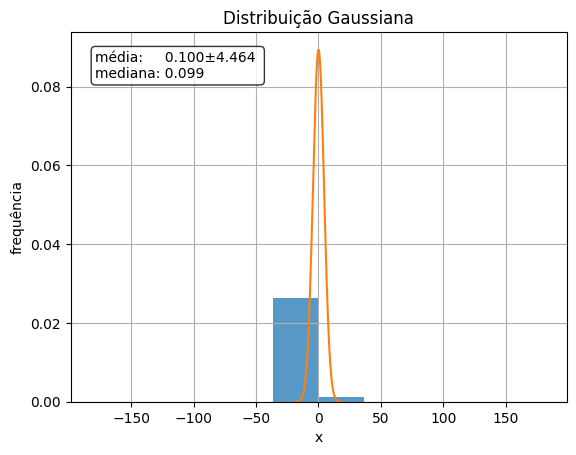

,time,ay,roll,wz,tmp,wy,pitch,e,wx,az,ax,yaw
0,0.0,9.785830,-0.641,0.11707,56.9,-0.15287,3.316,0.468,-0.02796,-0.069186,0.556008,12.163
1,0.1,9.769267,-0.593,-0.18520,56.5,-0.18329,3.356,0.288,-0.27558,-0.125839,0.593243,10.847
2,0.2,9.781947,-0.592,0.05711,56.7,-0.29671,3.356,0.288,-0.30478,-0.069961,0.594891,10.856
3,0.3,9.813770,-0.593,-0.19853,56.5,0.04674,3.353,0.288,0.26212,-0.133145,0.575013,10.859
4,0.4,9.784252,-0.592,0.29984,56.9,0.17612,3.357,0.288,0.09759,-0.116748,0.551908,10.870
...,...,...,...,...,...,...,...,...,...,...,...,...
3272,327.2,9.760441,-0.642,-0.12527,57.7,-0.19180,3.336,0.468,0.14780,-0.080522,0.612062,13.566
3273,327.3,9.755548,-0.644,0.17786,57.4,-0.00113,3.334,0.468,-0.06816,-0.101538,0.584261,13.567
3274,327.4,9.780986,-0.642,0.00658,57.4,0.04123,3.335,0.468,-0.11937,-0.149944,0.541082,13.568
3275,327.5,9.781319,-0.643,0.03740,57.7,-0.11121,3.334,0.468,-0.05677,-0.058938,0.583947,13.570


In [24]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()

def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time); plt.show()
df = normalizePeriod(df, 'time', dt)
df

# FILTRAGEM

In [25]:
class FrequencyAnalyzer:
    def __init__(self, xData, yData):
        self.xData = np.asarray(xData)
        self.yData = np.asarray(yData)
        
        self.dt = np.mean(np.diff(self.xData))
        self.nSamples = len(self.yData)
        
        self.yFreq = None
        self.yMag  = None

    def update(self):
        fftResult  = np.fft.fft(self.yData)
        freqs      = np.fft.fftfreq(self.nSamples, self.dt)
        self.yFreq = np.fft.fftshift(freqs)
        self.yMag  = np.fft.fftshift(np.abs(fftResult)) / self.nSamples

    def plot(self, xLim=None, yLim=None, Fc=None):
        self.update()

        plt.plot(self.yFreq, self.yMag, label='blue', color='red', alpha=0.5)

        if Fc is not None:
            yMagRestricted = self.yMag.copy()
            allowed = (np.abs(self.yFreq) <= Fc)
            yMagRestricted[~allowed] = 0
            plt.plot(self.yFreq, yMagRestricted, label=f'Fc={Fc}', color='blue')
        
        plt.xlabel('frequency')
        plt.ylabel('amplitude')
        plt.grid(alpha=0.3)
        
        if xLim: plt.xlim(xLim)
        if yLim: plt.ylim(yLim)
        plt.legend()


class LowPassFilter:
    def __init__(self, Fc, dt):
        self.dt = dt
        self.Fc = Fc
        
        Wc = (2 * np.pi * Fc) 
        s  = ctl.TransferFunction.s
        
        H   = Wc / (s + Wc)
        H_z = ctl.c2d(H, dt, method='tustin')
        
        self.num, self.den = self.getFraction(H_z)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))

    def getFraction(self, G_z):
        num, den = ctl.tfdata(G_z)
        num = np.squeeze(num)
        den = np.squeeze(den)

        num = num / den[0]
        den = den / den[0]
        return num.tolist(), den.tolist()

    def compute(self):
        out = 0.0
        for i in range(len(self.num)):
            out += self.Xn[i] * self.num[i]
        
        for i in range(1, len(self.den)):
            out -= self.Yn[i] * self.den[i]

        return out

    def update(self, inputValue):
        for n in range(len(self.num)-1, 0, -1):
            self.Xn[n] = self.Xn[n-1]

        for n in range(len(self.den)-1, 0, -1):
            self.Yn[n] = self.Yn[n-1]
        
        self.Xn[0] = inputValue
        self.Yn[0] = self.compute()
        return self.Yn[0] if self.Fc > 0 else inputValue

    def apply(self, yData):
        yData = np.array(yData)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))
        for i in range(100): self.update(yData[0])
        return np.array([self.update(val) for val in yData])

    def test(self, df, var, xLim, yLim, limits=(0, 100)):
        plt.figure(figsize=(17, 5))
        plt.subplot(1, 2, 1)
        print('testing', var)
        FrequencyAnalyzer(df.time, df[var]).plot(xLim, yLim, Fc=Fc)

        plt.subplot(1, 2, 2)
        target = df.loc[(df.time >= limits[0]) & (df.time <= limits[1])]
        plt.plot(target.time, target[var], label='values')
        plt.plot(target.time, self.apply(target[var]), label=f'Fc={Fc}', linewidth=2)
        plt.grid(alpha=0.3); plt.legend()
        plt.xlabel('time'); plt.ylabel('values')
        plt.show()
        df[var] = self.apply(df[var])
        return df.copy()


APPLY_FILTERS = False

if APPLY_FILTERS:
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'ax', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'ay', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'az', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))

    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wx', xLim=(-5, 5), yLim=(0, 0.1), limits=(50, 70))
    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wy', xLim=(-5, 5), yLim=(0, 0.1),  limits=(50, 70))
    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wz', xLim=(-5, 5), yLim=(0, 0.1), limits=(50, 70))

# SEPARAÇÃO DE TABELAS
- Juntando Amostragem pelos limites definidos

In [26]:
df_static  = df.loc[(df.time >= STATIC_LIMITS[0]) & (df.time <= STATIC_LIMITS[1])].copy()
df_dynamic = df.loc[(df.time > DYNAMIC_LIMITS[0]) & (df.time <= DYNAMIC_LIMITS[1])].copy() 

df_dynamic['static'] = False
df_static['static']  = True

df_dynamic.loc[:, 'time'] = (df_dynamic.time - df_dynamic.time.values[0])
df_static.loc[:, 'time']  = (df_static.time  - df_static.time.values[0])  + df_dynamic.time.values[-1]

df = pd.concat([df_dynamic, df_static], axis=0, ignore_index=True)
df

,time,ay,roll,wz,tmp,wy,pitch,e,wx,az,ax,yaw,static
0,0.0,9.816496,-0.971,-3.01151,56.9,0.00050,2.223,-0.684,0.54692,-0.072785,0.583564,11.628,False
1,0.1,9.770532,-0.901,-3.95340,57.0,0.45201,2.604,-0.468,0.72402,-0.107422,0.585722,11.625,False
2,0.2,9.784359,-0.824,-4.00435,56.9,-0.47514,3.016,-0.252,0.61244,-0.095164,0.561323,11.625,False
3,0.3,9.767002,-0.740,-4.19792,57.0,0.11488,3.447,0.036,0.63662,-0.081886,0.545456,11.633,False
4,0.4,9.806758,-0.656,-4.20634,56.9,-0.07570,3.871,0.432,0.71959,-0.108422,0.592724,11.639,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,129.5,9.774190,-0.638,-0.16637,57.4,-0.17294,3.337,0.468,-0.09776,-0.144550,0.576298,13.335,True
1297,129.6,9.744397,-0.634,-0.58104,57.4,0.22483,3.339,0.468,-0.06197,-0.093879,0.572355,13.338,True
1298,129.7,9.749781,-0.635,0.03523,57.3,0.03419,3.341,0.468,0.12510,-0.134322,0.562608,13.338,True
1299,129.8,9.735395,-0.634,0.23015,57.4,-0.15196,3.341,0.468,0.07650,-0.094516,0.592214,13.339,True


# FILTRANDO POR VARIAVEL

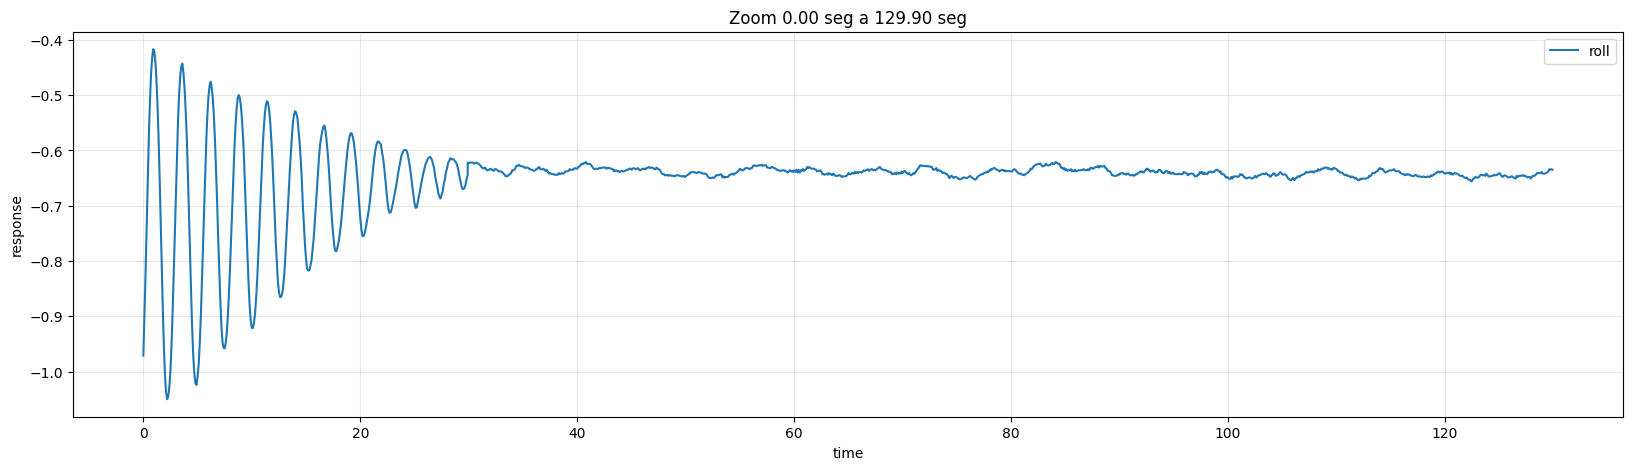

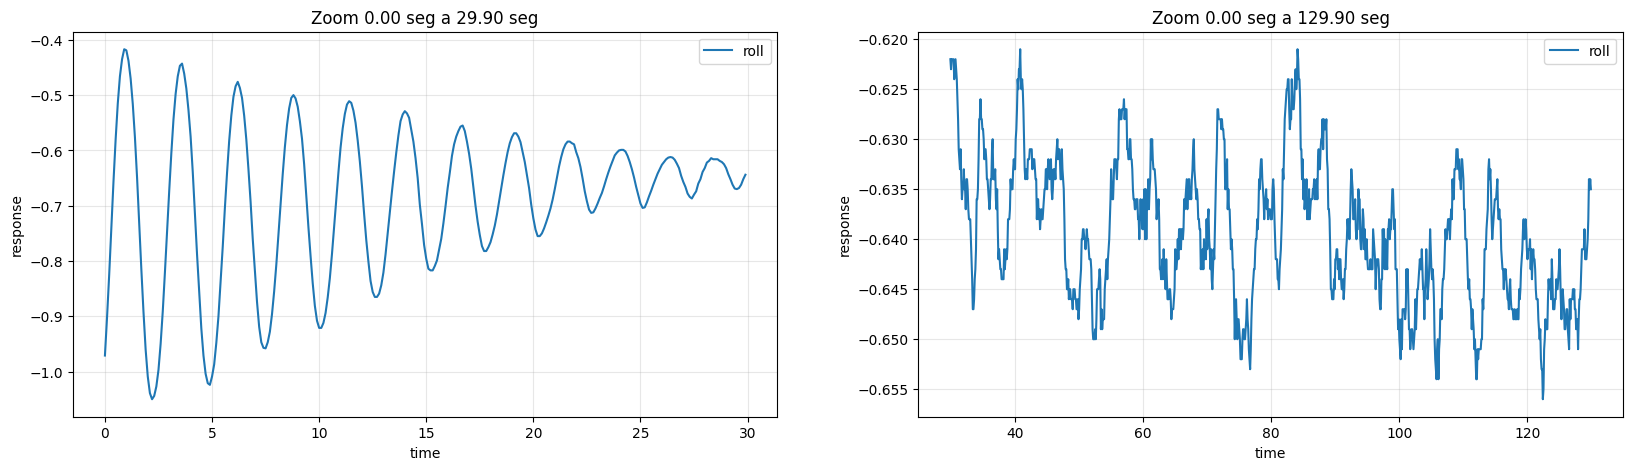

In [27]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plotViews(df, limits=(0, 1))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_dynamic, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df_static, limits=(0, 1))

# SALVANDO DADOS

In [28]:
df = df.rename(columns={col: 'target_' + col for col in df.columns if col not in ['time', 'static']})
df

,time,target_ay,target_roll,target_wz,target_tmp,target_wy,target_pitch,target_e,target_wx,target_az,target_ax,target_yaw,static
0,0.0,9.816496,-0.971,-3.01151,56.9,0.00050,2.223,-0.684,0.54692,-0.072785,0.583564,11.628,False
1,0.1,9.770532,-0.901,-3.95340,57.0,0.45201,2.604,-0.468,0.72402,-0.107422,0.585722,11.625,False
2,0.2,9.784359,-0.824,-4.00435,56.9,-0.47514,3.016,-0.252,0.61244,-0.095164,0.561323,11.625,False
3,0.3,9.767002,-0.740,-4.19792,57.0,0.11488,3.447,0.036,0.63662,-0.081886,0.545456,11.633,False
4,0.4,9.806758,-0.656,-4.20634,56.9,-0.07570,3.871,0.432,0.71959,-0.108422,0.592724,11.639,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,129.5,9.774190,-0.638,-0.16637,57.4,-0.17294,3.337,0.468,-0.09776,-0.144550,0.576298,13.335,True
1297,129.6,9.744397,-0.634,-0.58104,57.4,0.22483,3.339,0.468,-0.06197,-0.093879,0.572355,13.338,True
1298,129.7,9.749781,-0.635,0.03523,57.3,0.03419,3.341,0.468,0.12510,-0.134322,0.562608,13.338,True
1299,129.8,9.735395,-0.634,0.23015,57.4,-0.15196,3.341,0.468,0.07650,-0.094516,0.592214,13.339,True


In [29]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)